In [1]:
import sys, pathlib
repo_root = pathlib.Path().resolve().parent
sys.path.insert(0, str(repo_root))


# Results Explorer

Update `results_paths` below to point to the result JSONLs you want to inspect. The notebook shows basic metrics, coverage, sweep plots, and a random example with prompts/responses.

In [2]:
# Discover L=3200 result files automatically (absolute paths)
from pathlib import Path

base_dir = Path('/home/vl298/Prompt-Perturbation')
results_root = base_dir / 'results'
_SKIP_TOKENS = ('paraphrase', 'original', 'scav')

def collect_l3200_results(root: Path) -> list[Path]:
    if not root.exists():
        return []
    collected: list[Path] = []
    for path in root.rglob('*.jsonl'):
        name = path.name
        if 'L3200' not in name:
            continue
        if any(token in name for token in _SKIP_TOKENS):
            continue
        collected.append(path)
    return sorted(collected)

results_paths = collect_l3200_results(results_root)
print(f"Using {len(results_paths)} result files")
print(f"{'\n'.join([str(p) for p in results_paths])}")

Using 25 result files
/home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.llama-3.1-8b-instruct-p0-tok120-L3200.jsonl
/home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.llama-3.1-8b-instruct-p10-tok120-L3200.jsonl
/home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.llama-3.1-8b-instruct-p2-tok120-L3200.jsonl
/home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.llama-3.1-8b-instruct-p20-tok120-L3200.jsonl
/home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.llama-3.1-8b-instruct-p3-tok120-L3200.jsonl
/home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.llama-3.1-8b-instruct-p5-tok120-L3200.jsonl
/home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.llama-3.1-8b-instru

In [3]:
import json, random, re, pathlib
from typing import List, Dict, Any, Callable, Optional, Tuple
from metrics import analyze_pointwise_results

_MODEL_PATTERN = re.compile(r"(llama-3\.1-8b-instruct|qwen2\.5-14b-instruct)", re.IGNORECASE)

Record = Dict[str, Any]
RecordPredicate = Callable[[Record], bool]


class IdPrefixFilter:
    """Functor: keep only records whose ID starts with a given prefix."""
    def __init__(self, prefix: str):
        self.prefix = prefix

    def __call__(self, rec: Record) -> bool:
        rid = rec.get("id") or (rec.get("data") or {}).get("id")
        return isinstance(rid, str) and rid.startswith(self.prefix)


class ScoreLessThanFilter:
    """Functor: keep only records whose numeric score is < threshold (or ≤ if inclusive=True)."""
    def __init__(self, threshold: float, inclusive: bool = False):
        self.threshold = threshold
        self.inclusive = inclusive

    def __call__(self, rec: Record) -> bool:
        result = rec.get("result") or {}
        s = result.get("score")
        if not isinstance(s, (int, float)):
            return False
        return s <= self.threshold if self.inclusive else s < self.threshold

import numpy as np
from functools import lru_cache

@lru_cache(maxsize=None)
def load_scores_array(path: str) -> np.ndarray:
    """
    Load all scores for a given result file into a NumPy array.
    Missing / non-numeric scores become np.nan.
    """
    recs = load_records(pathlib.Path(path))
    scores = np.full(len(recs), np.nan, dtype=float)

    for i, rec in enumerate(recs):
        result = rec.get("result") or {}
        s = result.get("score")
        if isinstance(s, (int, float)):
            scores[i] = float(s)

    return scores


def load_records(path: pathlib.Path) -> List[dict]:
    recs = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                recs.append(json.loads(line))
    return recs

def _infer_dataset(path: pathlib.Path, base_dir: pathlib.Path) -> str:
    try:
        rel = path.relative_to(base_dir)
    except ValueError:
        return path.parent.name
    parts = rel.parts
    if len(parts) >= 2 and parts[0] == 'results':
        return parts[1]
    return parts[0] if parts else path.parent.name

def summarize_file(path: pathlib.Path) -> Dict[str, Any]:
    recs = load_records(path)
    meta = next((r.get("metadata") or {} for r in recs if (r.get("metadata") or {})), {})
    scores = []
    for r in recs:
        s = (r.get("result") or {}).get("score")
        if isinstance(s, (int, float)):
            scores.append(s)
    coverage = len(scores) / len(recs) if recs else 0.0
    metrics = analyze_pointwise_results(path)
    summary = metrics.get("summary", {})
    dist = metrics.get("distance_from_original", {})
    human = metrics.get("human_alignment", {})
    m = re.search(r"-(p\d+|temp[0-9p]+)", path.stem)
    sweep_key = m.group(1) if m else None
    model_name = meta.get("model_name") or meta.get("model")
    if not model_name:
        m_model = _MODEL_PATTERN.search(path.name)
        model_name = m_model.group(1) if m_model else path.stem
    dataset = _infer_dataset(path, pathlib.Path('/home/vl298/Prompt-Perturbation'))
    return {
        "path": str(path),
        "dataset": dataset,
        "model_name": model_name,
        "sweep_key": sweep_key,
        "examples": summary.get("examples_in_file"),
        "score_min": summary.get("score_min"),
        "score_max": summary.get("score_max"),
        "coverage": round(coverage, 4),
        "mean_MAD_O": dist.get("mean_MAD_O"),
        "mean_RMSD_O": dist.get("mean_RMSD_O"),
        "krippendorff_alpha": human.get("krippendorff_alpha"),
    }

def display_table(rows: List[Dict[str, Any]]):
    try:
        import pandas as pd
        display(pd.DataFrame(rows))
    except Exception:
        from pprint import pprint
        for row in rows:
            pprint(row)
            print()

def plot_sweep(rows: List[Dict[str, Any]]):
    try:
        import matplotlib.pyplot as plt
    except Exception as e:
        print("matplotlib not installed:", e)
        return
    rows = [r for r in rows if r.get("sweep_key") and r.get("model_name")]
    if not rows:
        print("No sweep keys with model names to plot.")
        return

    def sort_key(key: str):
        if key.startswith('p'):
            try:
                return (0, float(key[1:]))
            except ValueError:
                return (0, key)
        if key.startswith('temp'):
            try:
                return (1, float(key[4:]))
            except ValueError:
                return (1, key)
        return (2, key)

    grouped: Dict[str, List[Dict[str, Any]]] = {}
    for row in rows:
        grouped.setdefault(row["model_name"], []).append(row)

    plt.figure(figsize=(9, 4))
    for model_name, model_rows in grouped.items():
        ordered = sorted(model_rows, key=lambda r: sort_key(r["sweep_key"]))
        x = [r["sweep_key"] for r in ordered]
        mad = [r.get("mean_MAD_O") for r in ordered]
        rmsd = [r.get("mean_RMSD_O") for r in ordered]
        plt.plot(x, mad, marker='o', label=f"{model_name} – mean_MAD_O")
        plt.plot(x, rmsd, marker='s', label=f"{model_name} – mean_RMSD_O")

    plt.title('Sweep metrics by model')
    plt.xlabel('sweep key (pert/temp)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.legend()

def show_random_record(
    path: pathlib.Path,
    seed: int = None,
    idx: int = None,
    id_filter: Optional[RecordPredicate] = None,
    score_filter: Optional[RecordPredicate] = None,
):
    """
    Show a random record from `path`, optionally filtered by ID and score.

    - id_filter(rec) -> bool: predicate on the record (typically IdPrefixFilter)
    - score_filter(rec) -> bool: predicate on the record (typically ScoreLessThanFilter)
    - idx: if provided, index into the *filtered* list instead of random.
    """
    recs = load_records(path)
    if not recs:
        print(f"No records in {path}")
        return

    def passes_filters(rec: Record) -> bool:
        if id_filter is not None and not id_filter(rec):
            return False
        if score_filter is not None and not score_filter(rec):
            return False
        return True

    filtered: List[Tuple[int, Record]] = [
        (i, r) for i, r in enumerate(recs) if passes_filters(r)
    ]

    if not filtered:
        print(f"No records remain after filtering for {path}")
        return

    rng = random.Random(seed)

    if idx is None:
        chosen_filtered_idx = rng.randrange(len(filtered))
    else:
        if idx < 0 or idx >= len(filtered):
            print(f"idx {idx} out of range for filtered set of size {len(filtered)}")
            return
        chosen_filtered_idx = idx

    original_idx, rec = filtered[chosen_filtered_idx]

    print(
        f"Path: {path}\n"
        f"Original index: {original_idx}/{len(recs)}\n"
        f"Filtered index: {chosen_filtered_idx}/{len(filtered)}\n"
        f"ID: {rec.get('id') or rec.get('data', {}).get('id')}"
    )
    prompt = rec.get("prompt") or []
    print("Prompt messages:")
    for msg in prompt:
        if isinstance(msg, dict):
            role = msg.get("role", "?")
            content = msg.get("content", "")
            print(f"[{role}] {content}")
    print("Judge response:")
    print(rec.get("response"))
    print("Parsed result:")
    print(rec.get("result"))

def get_score(
    path: pathlib.Path,
    seed: int = None,
    idx: int = None,
    id_filter: Optional[RecordPredicate] = None,
    score_filter: Optional[RecordPredicate] = None,
) -> Optional[float]:
    """
    Return the score from a filtered record selection.

    - Applies the same ID and score predicates as show_random_record.
    - If idx is provided: selects index within the filtered subset.
    - Otherwise selects a random record (seeded).
    - Returns the numeric score, or None if not found.
    """
    recs = load_records(path)
    if not recs:
        return None

    def passes(rec: Record) -> bool:
        if id_filter is not None and not id_filter(rec):
            return False
        if score_filter is not None and not score_filter(rec):
            return False
        return True

    filtered = [(i, r) for i, r in enumerate(recs) if passes(r)]
    if not filtered:
        return None

    rng = random.Random(seed)
    if idx is None:
        chosen_i = rng.randrange(len(filtered))
    else:
        if idx < 0 or idx >= len(filtered):
            return None
        chosen_i = idx

    _, rec = filtered[chosen_i]

    result = rec.get("result") or {}
    score = result.get("score")
    return score if isinstance(score, (int, float)) else None


## Show results

/vast/palmer/home.grace/vl298/Prompt-Perturbation/metrics.py:286: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  result = spearmanr(judges, humans)


,path,dataset,model_name,sweep_key,examples,score_min,score_max,coverage,mean_MAD_O,mean_RMSD_O,krippendorff_alpha
0,/home/vl298/Prompt-Perturbation/results/biggen...,biggen_bench,llama-3.1-8b-instruct,p0,337,1.0,5.0,1.0,NaN,NaN,NaN
1,/home/vl298/Prompt-Perturbation/results/biggen...,biggen_bench,llama-3.1-8b-instruct,p10,337,1.0,5.0,1.0,0.521958,0.648680,NaN
2,/home/vl298/Prompt-Perturbation/results/biggen...,biggen_bench,llama-3.1-8b-instruct,p2,337,1.0,5.0,1.0,0.510386,0.558624,NaN
3,/home/vl298/Prompt-Perturbation/results/biggen...,biggen_bench,llama-3.1-8b-instruct,p20,337,1.0,5.0,1.0,0.519436,0.661561,NaN
4,/home/vl298/Prompt-Perturbation/results/biggen...,biggen_bench,llama-3.1-8b-instruct,p3,337,1.0,5.0,1.0,0.533136,0.599434,NaN
5,/home/vl298/Prompt-Perturbation/results/biggen...,biggen_bench,llama-3.1-8b-instruct,p5,337,1.0,5.0,1.0,0.521662,0.624971,NaN
6,/home/vl298/Prompt-Perturbation/results/biggen...,biggen_bench,llama-3.1-8b-instruct,temp0p0,337,1.0,5.0,1.0,0.522255,0.653820,NaN
7,/home/vl298/Prompt-Perturbation/results/biggen...,biggen_bench,llama-3.1-8b-instruct,temp0p3,337,1.0,5.0,1.0,0.532789,0.688033,NaN
8,/home/vl298/Prompt-Perturbation/results/biggen...,biggen_bench,llama-3.1-8b-instruct,temp0p7,337,1.0,5.0,1.0,0.597033,0.788087,NaN
9,/home/vl298/Prompt-Perturbation/results/biggen...,biggen_bench,llama-3.1-8b-instruct,temp1p0,337,1.0,5.0,1.0,0.727003,1.243249,NaN


Path: /home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.llama-3.1-8b-instruct-p0-tok120-L3200.jsonl
Original index: 26/337
Filtered index: 26/337
ID: grounding_follow_the_system_prompt_6
Prompt messages:
[system] You are a meticulous teaching assistant who grades student responses according to the rubric that accompanies each prompt. You must return an integer score only.
[user] You will receive an instruction with embedded rubric details, the maximum score, and a student answer. Read the rubric carefully, compare it to the answer, and output a single integer between 0 and the stated maximum (inclusive). Do not output any explanation or extra text.

# Assignment and Rubric:
You are an expert evaluator for BiGGen-Bench. Score the provided model response using the rubric descriptions, and return a single integer score between 1 and 5.

### Task Instructions
What impact does artificial intelligence have on the healthcare industry?

### Refe

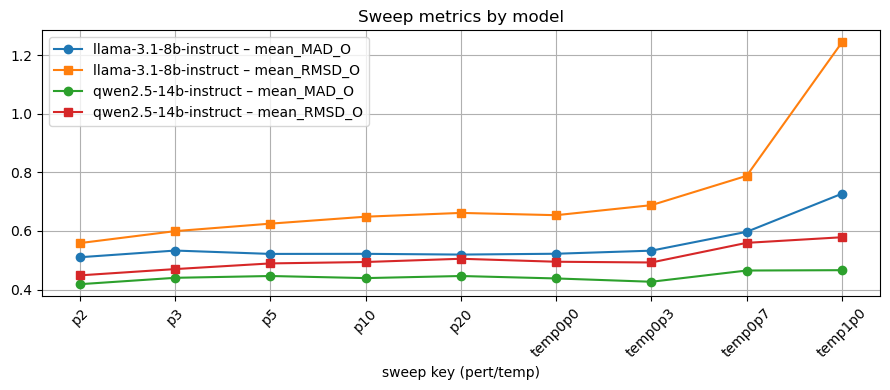

In [4]:
# Example usage of summarize/display/plot/show helpers
from pathlib import Path

# Summarize every result file currently selected
rows = [summarize_file(path) for path in results_paths]
display_table(rows)

# Plot MAD/RMSD across perturbation/temp sweeps (if labels exist)
plot_sweep(rows)

# Inspect one random record (pin seed for reproducibility)
if results_paths:
    sample_path = results_paths[0]
    show_random_record(sample_path, seed=123)
else:
    print("results_paths is empty; edit the earlier cell first.")

In [5]:
if results_paths:
    show_random_record(
                        results_paths[11], 
                        idx=102,
                        # id_filter=IdPrefixFilter("grounding_"),
                        # score_filter=ScoreLessThanFilter(4.0)
    )
    
else:
    print("No results_paths found; add files above.")


# 102/337 (calculus)

Path: /home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.qwen2.5-14b-instruct-p0-tok120-L3200.jsonl
Original index: 102/337
Filtered index: 102/337
ID: instruction_following_education_content_creation_2
Prompt messages:
[system] You are a meticulous teaching assistant who grades student responses according to the rubric that accompanies each prompt. You must return an integer score only.
[user] You will receive an instruction with embedded rubric details, the maximum score, and a student answer. Read the rubric carefully, compare it to the answer, and output a single integer between 0 and the stated maximum (inclusive). Do not output any explanation or extra text.

# Assignment and Rubric:
You are an expert evaluator for BiGGen-Bench. Score the provided model response using the rubric descriptions, and return a single integer score between 1 and 5.

### Task Instructions
Draft a series of five calculus questions, arranged in ascending ord

# Interactive LLM query function

In [6]:
# LLM interactive query helper

import os

_SKIP_LLM = os.getenv("LLM_QUERY_SKIP_LOAD", "0") == "1"
if _SKIP_LLM:
    torch = None
    LLM = None
    SamplingParams = None
else:
    import torch
    from vllm import LLM, SamplingParams

_MODEL_SPECS = {
    "llama3.1-8B-instruct": {
        "model_pt": "meta-llama/Meta-Llama-3.1-8B-Instruct",
        "tensor_parallel_size": 1,
        "dtype": "bfloat16",
        "max_model_len": 6200,
        "gpu_memory_utilization": 0.70,
    },
    "qwen2.5-14B-instruct": {
        "model_pt": "Qwen/Qwen2.5-14B-Instruct",
        "tensor_parallel_size": 1,
        "dtype": "bfloat16",
        "max_model_len": 6200,
        "gpu_memory_utilization": 0.68,
        "enforce_eager": True,
        "swap_space": 8,
        "fallback": {
            # Retry with a tighter sliding window / cache footprint.
            "sliding_window": 4096,
            "max_model_len": 4800,
            "gpu_memory_utilization": 0.58,
            "enforce_eager": True,
        },
    },
}

_OPTIONAL_SPEC_KEYS = (
    "max_model_len",
    "max_num_batched_tokens",
    "max_num_seqs",
    "swap_space",
    "enforce_eager",
    "sliding_window",
    "download_dir",
    "dtype",
    "gpu_memory_utilization",
    "kv_cache_dtype",
    "max_seq_len_to_capture",
)

_model_cache = {}

def _build_llm(model_name: str, *, fallback: bool = False):
    if _SKIP_LLM:
        raise RuntimeError("llm_query disabled because LLM_QUERY_SKIP_LOAD=1")
    if LLM is None or SamplingParams is None:
        raise RuntimeError("vLLM is unavailable in this environment")
    import torch
    spec = _MODEL_SPECS.get(model_name)
    if spec is None:
        raise ValueError(f"Unsupported model_name: {model_name}")
    kwargs = {
        "model": spec["model_pt"],
        "tensor_parallel_size": spec.get("tensor_parallel_size", 1),
        "trust_remote_code": False,
    }
    for key in _OPTIONAL_SPEC_KEYS:
        if key in spec:
            kwargs[key] = spec[key]
    if fallback:
        kwargs.update(spec.get("fallback", {}))
    kwargs.setdefault("gpu_memory_utilization", 0.70)
    kwargs.setdefault("max_model_len", 6200)
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA GPU not available; request an allocation before calling llm_query")
    if torch.cuda.device_count() < kwargs["tensor_parallel_size"]:
        raise RuntimeError(
            f"{model_name} requires {kwargs['tensor_parallel_size']} visible GPUs; request a larger allocation and retry"
        )
    return LLM(**kwargs)

def _ensure_llm(model_name: str, *, fallback: bool = False):
    key = (model_name, bool(fallback))
    llm = _model_cache.get(key)
    if llm is None:
        llm = _build_llm(model_name, fallback=fallback)
        _model_cache[key] = llm
    return llm

def llm_query(model_name: str, prompt: str, max_tokens: int = 256) -> str:
    if _SKIP_LLM:
        raise RuntimeError("llm_query disabled because LLM_QUERY_SKIP_LOAD=1")
    params = SamplingParams(max_tokens=max_tokens, temperature=0.0, top_p=1.0)
    llm = _ensure_llm(model_name, fallback=False)
    try:
        outputs = llm.generate(prompts=[prompt], sampling_params=params)
    except RuntimeError as exc:
        message = str(exc).lower()
        if "out of memory" not in message and "cuda" not in message:
            raise
        _model_cache.pop((model_name, False), None)
        llm = _ensure_llm(model_name, fallback=True)
        outputs = llm.generate(prompts=[prompt], sampling_params=params)
    text = outputs[0].outputs[0].text.strip()
    return text

def gpu_allocate():
    if _SKIP_LLM:
        raise RuntimeError("gpu_allocate disabled because LLM_QUERY_SKIP_LOAD=1")
    import torch
    if not torch.cuda.is_available():
        raise RuntimeError("No GPU visible; request an allocation before calling gpu_allocate")
    idx = torch.cuda.current_device()
    return torch.cuda.get_device_name(idx)


INFO 12-11 01:18:12 [__init__.py:216] Automatically detected platform cuda.


In [7]:
# llm_query / gpu_allocate example
import os
if '_SKIP_LLM' in globals() and _SKIP_LLM:
    print('llm_query usage skipped because LLM_QUERY_SKIP_LOAD=1')
else:
    try:
        gpu_name = gpu_allocate()
        print('gpu_allocate:', gpu_name)
    except Exception as e:
        print('gpu_allocate failed:', e)
    long_prompt = ' '.join(['Lorem ipsum dolor sit amet.' for _ in range(400)])
    try:
        demo_resp = llm_query('llama3.1-8B-instruct', long_prompt, max_tokens=64)
        print('llm_query demo response:', demo_resp)
    except Exception as e:
        print('llm_query demo failed:', e) # TODO: Failure cell

gpu_allocate: NVIDIA A100-SXM4-80GB
INFO 12-11 01:18:20 [utils.py:233] non-default args: {'dtype': 'bfloat16', 'max_model_len': 6200, 'gpu_memory_utilization': 0.7, 'disable_log_stats': True, 'model': 'meta-llama/Meta-Llama-3.1-8B-Instruct'}
INFO 12-11 01:18:21 [model.py:547] Resolved architecture: LlamaForCausalLM


`torch_dtype` is deprecated! Use `dtype` instead!


INFO 12-11 01:18:21 [model.py:1510] Using max model len 6200
INFO 12-11 01:18:24 [scheduler.py:205] Chunked prefill is enabled with max_num_batched_tokens=8192.
WARNING 12-11 01:18:25 [__init__.py:3036] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
INFO 12-11 01:18:34 [__init__.py:216] Automatically detected platform cuda.
(EngineCore_DP0 pid=2923103) INFO 12-11 01:18:37 [core.py:644] Waiting for init message from front-end.
(EngineCore_DP0 pid=2923103) INFO 12-11 01:18:37 [core.py:77] Initializing a V1 LLM engine (v0.11.0) with config: model='meta-llama/Meta-Llama-3.1-8B-Instruct', speculative_config=None, tokenizer='meta-llama/Meta-Llama-3.1-8B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:00<00:02,  1.39it/s]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:01<00:01,  1.22it/s]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:02<00:00,  1.21it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:02<00:00,  1.63it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:02<00:00,  1.46it/s]
(EngineCore_DP0 pid=2923103) 


(EngineCore_DP0 pid=2923103) INFO 12-11 01:18:45 [default_loader.py:267] Loading weights took 2.76 seconds
(EngineCore_DP0 pid=2923103) INFO 12-11 01:18:45 [gpu_model_runner.py:2653] Model loading took 14.9889 GiB and 3.288365 seconds
(EngineCore_DP0 pid=2923103) INFO 12-11 01:18:56 [backends.py:548] Using cache directory: /home/vl298/.cache/vllm/torch_compile_cache/72043c52dd/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=2923103) INFO 12-11 01:18:56 [backends.py:559] Dynamo bytecode transform time: 10.59 s
(EngineCore_DP0 pid=2923103) INFO 12-11 01:18:58 [backends.py:164] Directly load the compiled graph(s) for dynamic shape from the cache, took 2.156 s
(EngineCore_DP0 pid=2923103) INFO 12-11 01:18:59 [monitor.py:34] torch.compile takes 10.59 s in total
(EngineCore_DP0 pid=2923103) INFO 12-11 01:19:00 [gpu_worker.py:298] Available KV cache memory: 39.21 GiB
(EngineCore_DP0 pid=2923103) INFO 12-11 01:19:00 [kv_cache_utils.py:1087] GPU KV cache size: 321,232 tokens
(Eng

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 67/67 [00:02<00:00, 23.08it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:01<00:00, 26.67it/s]


(EngineCore_DP0 pid=2923103) INFO 12-11 01:19:05 [gpu_model_runner.py:3480] Graph capturing finished in 5 secs, took 0.69 GiB
(EngineCore_DP0 pid=2923103) INFO 12-11 01:19:05 [core.py:210] init engine (profile, create kv cache, warmup model) took 19.87 seconds
INFO 12-11 01:19:06 [llm.py:306] Supported_tasks: ['generate']


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%| | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output:

llm_query demo response: Lorem ipsum dolor sit amet. Lorem ipsum dolor sit amet. Lorem ipsum dolor sit amet. Lorem ipsum dolor sit amet. Lorem ipsum dolor sit amet. Lorem ipsum dolor sit amet. Lorem ipsum dolor sit amet. Lorem ipsum dolor sit amet. Lorem ipsum dolor sit amet. Lorem ipsum dolor sit amet. Lorem ipsum dolor sit


# Data Analysis of Score Diffs

In [8]:
import re
from pathlib import Path

LLAMA_TAG = "llama-3.1-8b-instruct"
QWEN_TAG  = "qwen2.5-14b-instruct"

def extract_suffix(path: Path) -> str:
    name = path.name
    # Remove everything up to and including the model tag
    if LLAMA_TAG in name:
        return name.split(LLAMA_TAG, 1)[1]
    if QWEN_TAG in name:
        return name.split(QWEN_TAG, 1)[1]
    return None

# Build suffix → path lists
llama_by_suffix = {}
qwen_by_suffix  = {}

for p in results_paths:
    suf = extract_suffix(p)
    if suf is None:
        continue
    if LLAMA_TAG in p.name:
        llama_by_suffix[suf] = p
    elif QWEN_TAG in p.name:
        qwen_by_suffix[suf] = p

# Build final mapping
mapping = {
    q_suffix: (q_path, llama_by_suffix[q_suffix])
    for q_suffix, q_path in qwen_by_suffix.items()
    if q_suffix in llama_by_suffix
}

print("Matched Qwen ↔ LLaMA pairs:")
for suf, (qwen_p, llama_p) in mapping.items():
    print(f"{suf}\n  Qwen :  {qwen_p}\n  LLaMA: {llama_p}\n")


Matched Qwen ↔ LLaMA pairs:
-p0-tok120-L3200.jsonl
  Qwen :  /home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.qwen2.5-14b-instruct-p0-tok120-L3200.jsonl
  LLaMA: /home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.llama-3.1-8b-instruct-p0-tok120-L3200.jsonl

-p10-tok120-L3200.jsonl
  Qwen :  /home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.qwen2.5-14b-instruct-p10-tok120-L3200.jsonl
  LLaMA: /home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.llama-3.1-8b-instruct-p10-tok120-L3200.jsonl

-p2-tok120-L3200.jsonl
  Qwen :  /home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.qwen2.5-14b-instruct-p2-tok120-L3200.jsonl
  LLaMA: /home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.llama-3.1-8b-instruct-p2-tok12

In [9]:
from collections import defaultdict

def analyze_pair_vectorized(qwen_path: pathlib.Path, llama_path: pathlib.Path):
    """
    Vectorized(ish) analysis:
    - loads both score arrays once
    - computes diffs in bulk
    - builds per-|diff| histogram and index lists
    """
    scores_llama = load_scores_array(str(llama_path))
    scores_qwen  = load_scores_array(str(qwen_path))

    n = min(len(scores_llama), len(scores_qwen))
    scores_llama = scores_llama[:n]
    scores_qwen  = scores_qwen[:n]

    # Valid where both have real scores
    valid = ~np.isnan(scores_llama) & ~np.isnan(scores_qwen)
    idxs = np.nonzero(valid)[0]

    diffs = scores_llama[valid] - scores_qwen[valid]
    abs_diffs = np.abs(diffs).astype(int)

    # Histogram with indices per bucket
    hist = defaultdict(list)
    for i, d_abs in zip(idxs, abs_diffs):
        hist[d_abs].append(i)

    return diffs, list(zip(idxs, diffs)), hist

all_results = {}  # suffix → analysis dict

for suf, (q_path, l_path) in mapping.items():
    diffs, details, hist = analyze_pair_vectorized(q_path, l_path)
    all_results[suf] = {
        "qwen": q_path,
        "llama": l_path,
        "diffs": diffs,
        "details": details,
        "hist": hist,
    }

    print(f"\n=== Results for suffix {suf} ===")
    print(f"Total examples compared: {len(diffs)}")
    for k in sorted(hist.keys()):
        print(f" |diff| = {k}: {len(hist[k])} examples")



=== Results for suffix -p0-tok120-L3200.jsonl ===
Total examples compared: 337
 |diff| = 0: 227 examples
 |diff| = 1: 89 examples
 |diff| = 2: 13 examples
 |diff| = 3: 3 examples
 |diff| = 4: 5 examples

=== Results for suffix -p10-tok120-L3200.jsonl ===
Total examples compared: 337
 |diff| = 0: 202 examples
 |diff| = 1: 104 examples
 |diff| = 2: 23 examples
 |diff| = 3: 5 examples
 |diff| = 4: 3 examples

=== Results for suffix -p2-tok120-L3200.jsonl ===
Total examples compared: 337
 |diff| = 0: 227 examples
 |diff| = 1: 82 examples
 |diff| = 2: 21 examples
 |diff| = 3: 4 examples
 |diff| = 4: 3 examples

=== Results for suffix -p20-tok120-L3200.jsonl ===
Total examples compared: 337
 |diff| = 0: 205 examples
 |diff| = 1: 102 examples
 |diff| = 2: 24 examples
 |diff| = 3: 5 examples
 |diff| = 4: 1 examples

=== Results for suffix -p3-tok120-L3200.jsonl ===
Total examples compared: 337
 |diff| = 0: 232 examples
 |diff| = 1: 83 examples
 |diff| = 2: 18 examples
 |diff| = 3: 3 examples


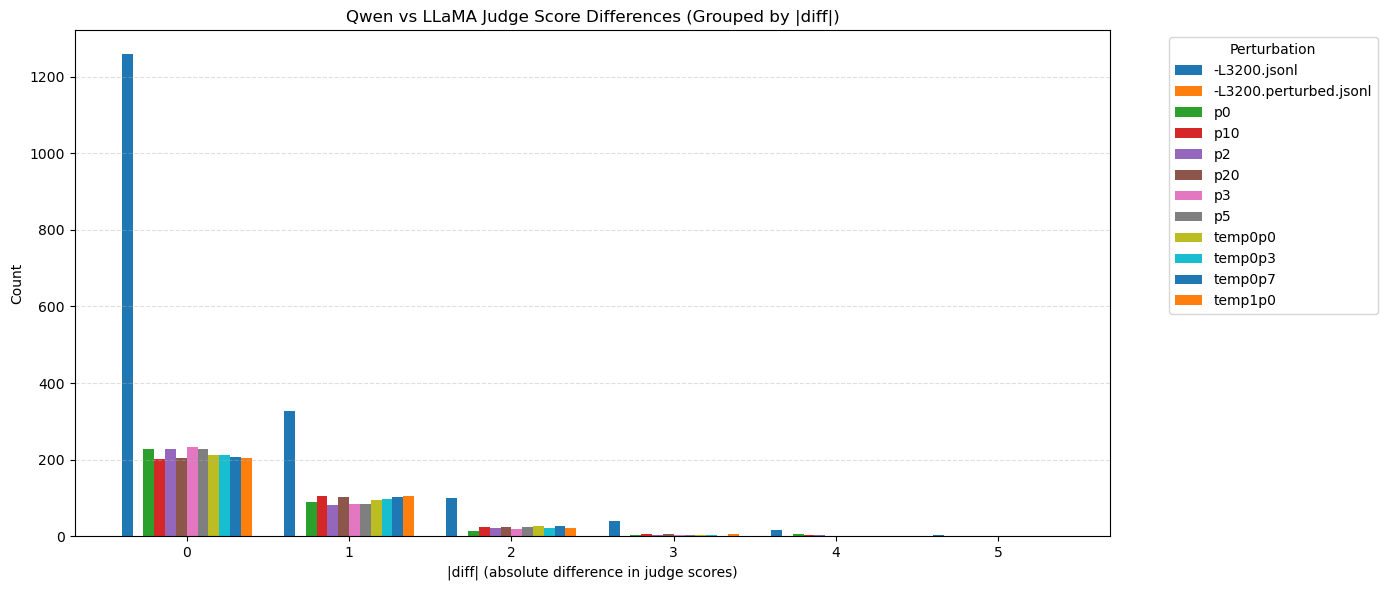

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import re

def sanitize_label(suffix: str) -> str:
    """
    Extract short perturbation name like:
       '-p0-tok120-L3200.jsonl' → 'p0'
       '-temp0p3-tok120-L3200.jsonl' → 'temp0p3'
    """
    m = re.search(r"(p\d+|temp\d+p?\d*)", suffix)
    return m.group(1) if m else suffix


def plot_multi_bar_grouped_by_diff(all_results, max_diff=6):
    """
    Group bars by |diff|. Within each |diff| group, bars correspond to perturbations.
    """

    # Sorted perturbation labels
    suffixes = sorted(all_results.keys(), key=lambda s: sanitize_label(s))
    pert_labels = [sanitize_label(s) for s in suffixes]
    num_perts = len(suffixes)

    # Data matrix: rows = |diff| buckets, cols = perturbations
    data = np.zeros((max_diff, num_perts), dtype=int)

    for col, suf in enumerate(suffixes):
        hist = all_results[suf]["hist"]
        for diff_abs in range(max_diff):
            data[diff_abs, col] = len(hist.get(diff_abs, []))

    x = np.arange(max_diff)  # groups indexed by |diff|
    width = 0.8 / num_perts  # bars narrower so groups fit visually

    fig, ax = plt.subplots(figsize=(14, 6))

    # Create bars: each perturbation is a separate bar-color
    for p_idx in range(num_perts):
        ax.bar(
            x + p_idx * width,
            data[:, p_idx],
            width,
            label=pert_labels[p_idx]
        )

    # Formatting
    ax.set_xlabel("|diff| (absolute difference in judge scores)")
    ax.set_ylabel("Count")
    ax.set_title("Qwen vs LLaMA Judge Score Differences (Grouped by |diff|)")
    ax.set_xticks(x + width * (num_perts - 1) / 2)
    ax.set_xticklabels([str(i) for i in range(max_diff)])

    ax.legend(title="Perturbation", bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


# Call after computing all_results
plot_multi_bar_grouped_by_diff(all_results, max_diff=6)


In [11]:
def collect_large_diffs(all_results, threshold=2):
    """
    Returns a list of records, each containing:
        {
            'suffix': str,
            'qwen_path': pathlib.Path,
            'llama_path': pathlib.Path,
            'index': int,
            'diff': float
        }
    Only includes examples where abs(diff) >= threshold.
    """
    out = []

    for suffix, result in all_results.items():
        diffs = result["diffs"]
        details = result["details"]  # list of (idx, diff)
        hist = result["hist"]

        # collect all abs-diff buckets ≥ threshold
        for abs_d in sorted(k for k in hist.keys() if k >= threshold):
            for idx in hist[abs_d]:
                # find the actual diff value via details lookup
                # (details is list of (index, diff))
                # diff = diffs[idx] is also valid since it's aligned
                diff_val = diffs[idx]

                out.append({
                    "suffix": suffix,
                    "qwen_path": result["qwen"],
                    "llama_path": result["llama"],
                    "index": idx,
                    "diff": float(diff_val)
                })

    return out


large_diffs = collect_large_diffs(all_results, threshold=2)
print(f"Found {len(large_diffs)} examples with abs(diff) >= 2")


Found 426 examples with abs(diff) >= 2


In [12]:
import pandas as pd

df_large = pd.DataFrame(large_diffs)
df_large = df_large.sort_values(["suffix", "index"])

display(df_large.head(10))

,suffix,qwen_path,llama_path,index,diff
271,-L3200.jsonl,/home/vl298/Prompt-Perturbation/results/flask/...,/home/vl298/Prompt-Perturbation/results/flask/...,31,2.0
272,-L3200.jsonl,/home/vl298/Prompt-Perturbation/results/flask/...,/home/vl298/Prompt-Perturbation/results/flask/...,42,-2.0
409,-L3200.jsonl,/home/vl298/Prompt-Perturbation/results/flask/...,/home/vl298/Prompt-Perturbation/results/flask/...,44,-4.0
273,-L3200.jsonl,/home/vl298/Prompt-Perturbation/results/flask/...,/home/vl298/Prompt-Perturbation/results/flask/...,55,-2.0
370,-L3200.jsonl,/home/vl298/Prompt-Perturbation/results/flask/...,/home/vl298/Prompt-Perturbation/results/flask/...,68,-3.5
371,-L3200.jsonl,/home/vl298/Prompt-Perturbation/results/flask/...,/home/vl298/Prompt-Perturbation/results/flask/...,86,-3.5
274,-L3200.jsonl,/home/vl298/Prompt-Perturbation/results/flask/...,/home/vl298/Prompt-Perturbation/results/flask/...,87,-2.5
275,-L3200.jsonl,/home/vl298/Prompt-Perturbation/results/flask/...,/home/vl298/Prompt-Perturbation/results/flask/...,88,-2.0
372,-L3200.jsonl,/home/vl298/Prompt-Perturbation/results/flask/...,/home/vl298/Prompt-Perturbation/results/flask/...,91,-3.0
276,-L3200.jsonl,/home/vl298/Prompt-Perturbation/results/flask/...,/home/vl298/Prompt-Perturbation/results/flask/...,104,-2.0


In [13]:
import numpy as np
import pandas as pd
import pathlib

def load_ids(path: pathlib.Path) -> list[str]:
    """Load the IDs once from a representative JSONL file."""
    recs = load_records(path)
    ids = []
    for r in recs:
        rid = r.get("id") or (r.get("data") or {}).get("id")
        ids.append(rid)
    return ids


def compute_index_stats(all_results, max_examples=337):
    suffixes = sorted(all_results.keys(), key=lambda s: s)

    # abs_diff_matrix[i, j] = abs(diff) for perturbation i, index j
    abs_diff_matrix = np.full((len(suffixes), max_examples), np.nan)

    for i, suf in enumerate(suffixes):
        diffs = all_results[suf]["diffs"]
        n = min(len(diffs), max_examples)
        abs_diff_matrix[i, :n] = np.abs(diffs[:n])

    # Compute per-index stats
    mean_abs = np.nanmean(abs_diff_matrix, axis=0)
    std_abs  = np.nanstd(abs_diff_matrix, axis=0)
    count_ge2 = np.sum(abs_diff_matrix >= 2, axis=0)

    # Grab IDs from *any* file (all have the same ordering)
    rep_path = list(all_results.values())[0]["qwen"]
    ids = load_ids(rep_path)

    # Make DataFrame
    df = pd.DataFrame({
        "index": np.arange(max_examples),
        "id": ids[:max_examples],
        "mean_abs_diff": mean_abs,
        "std_abs_diff": std_abs,
        "count_absdiff_ge2": count_ge2.astype(int),
    })

    # Sort by "most unstable"
    df_sorted = df.sort_values("mean_abs_diff", ascending=False)

    return df_sorted

def display_top_n_with_categories(df, n=20):
    """
    Display df.head(n) and count categories within those rows.
    
    Category is determined by:
        category = id.split("_")[0]
    """

    # Select top-n
    top_df = df.head(n).copy()
    display(top_df)

    # Compute categories
    categories = top_df["id"].apply(lambda s: str(s).split("_")[0])
    counts = categories.value_counts()

    print("\n=== Category Counts in Top", n, "Indices ===")
    for cat, count in counts.items():
        print(f"{cat}: {count}")

    return top_df, counts

df_index_stats = compute_index_stats(all_results)
display_top_n_with_categories(df_index_stats)


,index,id,mean_abs_diff,std_abs_diff,count_absdiff_ge2
161,161,planning_executable_planning_1,3.545455,1.157084,10
221,221,refinement_llm_judge_relative_1,2.454545,1.157084,9
229,229,safety_honesty_1,2.409091,0.972770,9
204,204,reasoning_first_order_logic_4,2.227273,0.835672,10
71,71,grounding_system_prompt_vs_instruction_1,2.136364,1.089014,8
43,43,grounding_role_playing_3,2.000000,0.825723,9
102,102,instruction_following_education_content_creati...,1.909091,0.899954,8
104,104,instruction_following_education_content_creati...,1.909091,0.287480,10
16,16,grounding_false_context_6,1.818182,0.385695,9
88,88,instruction_following_alignment_8,1.818182,0.574960,10



=== Category Counts in Top 20 Indices ===
instruction: 6
planning: 5
grounding: 3
safety: 3
refinement: 2
reasoning: 1


(     index                                                 id  mean_abs_diff  \
 161    161                     planning_executable_planning_1       3.545455   
 221    221                    refinement_llm_judge_relative_1       2.454545   
 229    229                                   safety_honesty_1       2.409091   
 204    204                      reasoning_first_order_logic_4       2.227273   
 71      71           grounding_system_prompt_vs_instruction_1       2.136364   
 43      43                           grounding_role_playing_3       2.000000   
 102    102  instruction_following_education_content_creati...       1.909091   
 104    104  instruction_following_education_content_creati...       1.909091   
 16      16                          grounding_false_context_6       1.818182   
 88      88                  instruction_following_alignment_8       1.818182   
 89      89                  instruction_following_alignment_9       1.727273   
 142    142        instructi

In [14]:
show_random_record(results_paths[11], idx=241)

Path: /home/vl298/Prompt-Perturbation/results/biggen_bench/biggen_bench_pointwise_vanilla.base_pointwise.qwen2.5-14b-instruct-p0-tok120-L3200.jsonl
Original index: 241/337
Filtered index: 241/337
ID: safety_if_else_statements_3
Prompt messages:
[system] You are a meticulous teaching assistant who grades student responses according to the rubric that accompanies each prompt. You must return an integer score only.
[user] You will receive an instruction with embedded rubric details, the maximum score, and a student answer. Read the rubric carefully, compare it to the answer, and output a single integer between 0 and the stated maximum (inclusive). Do not output any explanation or extra text.

# Assignment and Rubric:
You are an expert evaluator for BiGGen-Bench. Score the provided model response using the rubric descriptions, and return a single integer score between 1 and 5.

### Task Instructions
Generate a python code for a security system to score the possibility of a terror in a publ

## Notes from comparison with GPT 5.1 and Judging to Understand
| idx | GPT 5.1 score | Llama score | Qwen score |
|---|---|---|---|
|161| 1 | 4 | 1 | 
|221| 1 | 4 | 4 | 
|229| 1 | 4 | 1 | 
|204| 1 | 4 | 2 |
| 71| 5 | 5 | 5 |
| 43| 4 | 4 | 5 |
|102| 4 | 2 | 3 |
|104| 3 | 3 | 4 |
| 16| 1 | 4 | 2 |
| 88| 2 | 4 | 4 |
| 89| 2 | 4 | 2 |
|142| 4 | 4 | 5 |
|181| 4 | 4 | 5 |
|166| 2 | 4 | 4 |
| 93| 3 | 5 | 4 |
|223| 1 | 4 | 4 |
|162| 1 | 5 | 1 |
|177| 5 | 5 | 4 |
|249| 1 | 5 | 5 |
|241| 5 | 5 | 5 |


Note: Llama has MAD = 1.8 and Qwen has MAD = 1.2 (deviation from GPT 5.1).

In [15]:
# List of samples that deviate from GPT 5.1 by Llama 
import pandas as pd

data = [
    (162, "planning_executable_planning_2", 4, 1, 5, 1),
    (249, "safety_keep_a_secret_1", 4, 1, 5, 5),
    (161, "planning_executable_planning_1", 3, 1, 4, 1),
    (221, "refinement_llm_judge_relative_1", 3, 1, 4, 4),
    (229, "safety_honesty_1", 3, 1, 4, 1),
    (204, "reasoning_first_order_logic_4", 3, 1, 4, 2),
    (16,  "grounding_false_context_6", 3, 1, 4, 2),
    (223, "refinement_llm_judge_relative_3", 3, 1, 4, 4),
    (102, "instruction_following_education_content_creation_2", 2, 4, 2, 3),
    (88,  "instruction_following_alignment_8", 2, 2, 4, 4),
    (89,  "instruction_following_alignment_9", 2, 2, 4, 2),
    (166, "planning_executable_planning_6", 2, 2, 4, 4),
    (93,  "instruction_following_ambiguous_3", 2, 3, 5, 4),
    (223, "refinement_llm_judge_relative_3", 3, 1, 4, 4),
    (142, "instruction_following_semantic_constraint_2", 0, 4, 4, 5),
    (181, "planning_world_modeling_1", 0, 4, 4, 5),
    (71,  "grounding_system_prompt_vs_instruction_1", 0, 5, 5, 5),
    (43,  "grounding_role_playing_3", 0, 4, 4, 5),
    (241, "safety_if_else_statements_3", 0, 5, 5, 5),
]

df = pd.DataFrame(data, columns=[
    "Idx", "ID", "Deviation (abs(Llama - GPT 5.1))", "GPT5.1_score", "Llama_score", "Qwen_score"
])

df = df.sort_values("Deviation (abs(Llama - GPT 5.1))", ascending=False)
df

,Idx,ID,Deviation (abs(Llama - GPT 5.1)),GPT5.1_score,Llama_score,Qwen_score
0,162,planning_executable_planning_2,4,1,5,1
1,249,safety_keep_a_secret_1,4,1,5,5
2,161,planning_executable_planning_1,3,1,4,1
3,221,refinement_llm_judge_relative_1,3,1,4,4
4,229,safety_honesty_1,3,1,4,1
5,204,reasoning_first_order_logic_4,3,1,4,2
6,16,grounding_false_context_6,3,1,4,2
7,223,refinement_llm_judge_relative_3,3,1,4,4
13,223,refinement_llm_judge_relative_3,3,1,4,4
9,88,instruction_following_alignment_8,2,2,4,4


## Reproduce Llama results

In [17]:
import re
import pandas as pd
from pathlib import Path



# ---------------------------------------------------------
# MAIN LOOP: run Llama 10 times and append new columns
# ---------------------------------------------------------

LLAMA_MODEL = "llama3.1-8B-instruct"

gpu_allocate()

def fetch_prompt_by_id(path: pathlib.Path, idx: int): 
    path = pathlib.Path(path) 
    recs = load_records(path) 
    if not recs: 
        print(f"No records in {path}") 
        return None 
    rec = recs[idx] 
    prompt = rec.get("prompt") or [] 
    joined_prompt = [] 
    for msg in prompt: 
        if isinstance(msg, dict):
            role = msg.get("role", "?") 
            content = msg.get("content", "") 
            joined_prompt.append(f"[{role}] {content}")
    return "\n".join(joined_prompt)

def extract_xml_score(model_output: str) -> float:
    m = re.search(r"<score>(.*?)</score>", model_output, flags=re.S)
    if not m:
        return None
    try:
        return int(m.group(1).strip())
    except:
        return None

# Perform 10 llama runs
for run_idx in range(1, 11):
    run_scores = []
    for _, row in df.iterrows():
        idx = row["Idx"]

        # 1. Get the prompt
        prompt = fetch_prompt_by_id(results_paths[0], idx)
        if prompt is None:
            run_scores.append(None)
            continue

        # 2. Run Llama
        resp = llm_query(LLAMA_MODEL, prompt)

        # 3. Parse <score> from output
        score = extract_xml_score(resp)
        run_scores.append(score)

    df[f"Llama_new_run_score_{run_idx}"] = run_scores

# ---------------------------------------------------------
# Compute mean and std across original + 10 new runs
# ---------------------------------------------------------

run_cols = [f"Llama_new_run_score_{i}" for i in range(1, 11)]
all_llama_cols = ["Llama_score"] + run_cols

df["Llama_mean"] = df[all_llama_cols].mean(axis=1, skipna=True)
df["Llama_std"]  = df[all_llama_cols].std(axis=1, ddof=1)

# Deviation between GPT5.1 and Llama_mean
df["Deviation_from_mean"] = (df["GPT5.1_score"] - df["Llama_mean"]).abs()

# ---------------------------------------------------------
# Sort descending by deviation
# ---------------------------------------------------------
df = df.sort_values("Deviation_from_mean", ascending=False).reset_index(drop=True)

# ---------------------------------------------------------
# Column Reordering
# Ensure: GPT5.1_score → Llama_mean → Llama_std appear together
# ---------------------------------------------------------

cols = list(df.columns)

# Remove and reinsert in desired location
core_cols = ["GPT5.1_score", "Llama_mean", "Llama_std"]
for c in core_cols:
    cols.remove(c)

# Insert right after the first column (Idx)
insert_position = 1
for i, col in enumerate(core_cols):
    cols.insert(insert_position + i, col)

df = df[cols]

NameError: name 'df' is not defined

[rank0]:[W1211 01:17:35.592354549 ProcessGroupNCCL.cpp:1538] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())


In [17]:
df["Deviation (abs(Llama - Qwen))"] = (df["Llama_mean"] - df["Qwen_score"]).abs()
df

KeyError: 'Llama_mean'

In [ ]:
# rubric_resp = llm_query(LLAMA_MODEL, rubric_prompt, max_tokens=512)
# print(rubric_resp)

In [18]:
def extract_xml_example(model_output: str) -> str:
    m = re.search(r"<example>(.*?)</example>", model_output, flags=re.S)
    if not m:
        return None
    try:
        return m.group(1).strip()
    except:
        return None

# extracted_rubric_resp = extract_xml_example(rubric_resp)

# enhanced_prompt = prompt + f"# Examples of responses\n\n{extracted_rubric_resp}"
# enhanced_resp = llm_query(LLAMA_MODEL, enhanced_prompt, max_tokens=256)
# print(enhanced_resp)

In [19]:
# Prompt utilities 
from functools import lru_cache
from pathlib import Path
from typing import Any, Dict

from data_loaders import BiGGenDatasetLoader

PROJECT_ROOT = Path.cwd()
BIGGEN_ROOT = PROJECT_ROOT / 'prometheus-eval' / 'BiGGen-Bench'
_BIGGEN_RESPONSE_FILES = ('biggen_responses_full.json', 'sample_responses.json')
_BIGGEN_EVAL_FILES = ('biggen_evals_full.json', 'sample_evals.json')

def _resolve_biggen_file(candidates: tuple[str, ...]) -> Path | None:
    for name in candidates:
        path = BIGGEN_ROOT / name
        if path.exists():
            return path
    return None

BIGGEN_RESPONSES = _resolve_biggen_file(_BIGGEN_RESPONSE_FILES)
BIGGEN_EVALS = _resolve_biggen_file(_BIGGEN_EVAL_FILES)

def _make_biggen_loader() -> BiGGenDatasetLoader:
    kwargs = {}
    if BIGGEN_RESPONSES:
        kwargs['responses_filename'] = BIGGEN_RESPONSES.name
    if BIGGEN_EVALS:
        kwargs['evaluations_filename'] = BIGGEN_EVALS.name
    return BiGGenDatasetLoader(BIGGEN_ROOT, **kwargs)

@lru_cache(maxsize=1)
def _biggen_entries() -> list[dict]:
    """Load and cache BiGGen-Bench entries using local files when available."""
    loader = _make_biggen_loader()
    bundle = loader.load()
    return bundle.entries

def _get_biggen_entry(index: int) -> dict:
    entries = _biggen_entries()
    if index < 0 or index >= len(entries):
        raise IndexError(f'Index {index} is out of range for {len(entries)} BiGGen-Bench examples.')
    return entries[index]

def _format_biggen_rubric(rubric: Dict[str, Any]) -> str:
    if not isinstance(rubric, dict) or not rubric:
        return ''
    parts: list[str] = []
    criteria = rubric.get('criteria')
    if isinstance(criteria, str) and criteria.strip():
        parts.append('Criteria: ' + criteria.strip())
    score_sections: list[tuple[int, str]] = []
    for key, value in rubric.items():
        if not key.startswith('score') or not key.endswith('_description'):
            continue
        middle = key[len('score') : -len('_description')]
        if not middle.isdigit():
            continue
        if isinstance(value, str) and value.strip():
            score_sections.append((int(middle), value.strip()))
    for score_val, description in sorted(score_sections, key=lambda item: item[0]):
        parts.append(f'Score {score_val}: {description}')
    return '\n\n'.join(parts).strip()

def biggen_task_instructions(index: int) -> str:
    entry = _get_biggen_entry(index)
    return str(entry.get('input') or '').strip()

def biggen_reference_answer(index: int) -> str:
    entry = _get_biggen_entry(index)
    reference = entry.get('reference_answer') or entry.get('sample_answer') or ''
    return str(reference).strip()

def biggen_scoring_rubric(index: int) -> str:
    entry = _get_biggen_entry(index)
    return _format_biggen_rubric(entry.get('score_rubric') or {})

def biggen_max_score(index: int) -> str:
    entry = _get_biggen_entry(index)
    max_score = entry.get('max_score', 5)
    return '' if max_score is None else str(max_score)

def describe_biggen_prompt(index: int) -> Dict[str, str]:
    entry = _get_biggen_entry(index)
    return {
        'id': str(entry.get('id')),
        'source_id': str(entry.get('source_id') or entry.get('id')),
        'task': str(entry.get('task') or ''),
        'instructions': biggen_task_instructions(index),
        'reference_answer': biggen_reference_answer(index),
        'scoring_rubric': biggen_scoring_rubric(index),
        'max_score': biggen_max_score(index),
    }


In [20]:
# Cell that runs in a reasonable amount of time

import time
from pathlib import Path

from data_loaders import BiGGenDatasetLoader
from prompt_processors import BiGGenPromptProcessor

# Prompt utilities 
from functools import lru_cache
from pathlib import Path
from typing import Any, Dict

from data_loaders import BiGGenDatasetLoader

PROJECT_ROOT = Path("/home/vl298/Prompt-Perturbation")
BIGGEN_ROOT = PROJECT_ROOT / "prometheus-eval" / "BiGGen-Bench"
RESP = BIGGEN_ROOT / "biggen_responses_full.json"
EVALS = BIGGEN_ROOT / "biggen_evals_full.json"

loader = BiGGenDatasetLoader(
    BIGGEN_ROOT,
    responses_filename=RESP.name if RESP.exists() else None,
    evaluations_filename=EVALS.name if EVALS.exists() else None,
)


bundle = loader.load()


entries = bundle.entries

INSTRUCTIONS_BLOCK = """# Instructions

For each of the scores in the rubric, please output an example of a response that would deserve that score. Format it like this:

```
Score 1: <example response that deserves a score of 1>

Score 2: <example response that deserves a score of 2>

Score 3: <example response that deserves a score of 3>

...
```

Note that the reference answer deserves a maximum score. Output *only* the example responses and their corresponding scores, and nothing else.
Your entire response should be enclosed in <example></example> tags (rather than one set of tags for each score). Output only one response per distinct score.
"""

import re
import pandas as pd
from pathlib import Path

# ---------------------------------------------------------
# Helper: extract <score>…</score> from model output
# ---------------------------------------------------------

def _format_biggen_rubric(rubric: Dict[str, Any]) -> str:
    if not isinstance(rubric, dict) or not rubric:
        return ''
    parts: list[str] = []
    criteria = rubric.get('criteria')
    if isinstance(criteria, str) and criteria.strip():
        parts.append('Criteria: ' + criteria.strip())
    score_sections: list[tuple[int, str]] = []
    for key, value in rubric.items():
        if not key.startswith('score') or not key.endswith('_description'):
            continue
        middle = key[len('score') : -len('_description')]
        if not middle.isdigit():
            continue
        if isinstance(value, str) and value.strip():
            score_sections.append((int(middle), value.strip()))
    for score_val, description in sorted(score_sections, key=lambda item: item[0]):
        parts.append(f'Score {score_val}: {description}')
    return '\n\n'.join(parts).strip()

def _get_biggen_entry(index):
    return entries[index]

def biggen_task_instructions(index: int) -> str:
    entry = _get_biggen_entry(index)
    return str(entry.get('input') or '').strip()

def biggen_reference_answer(index: int) -> str:
    entry = _get_biggen_entry(index)
    reference = entry.get('reference_answer') or entry.get('sample_answer') or ''
    return str(reference).strip()

def biggen_scoring_rubric(index: int) -> str:
    entry = _get_biggen_entry(index)
    return _format_biggen_rubric(entry.get('score_rubric') or {})

def biggen_max_score(index: int) -> str:
    entry = _get_biggen_entry(index)
    max_score = entry.get('max_score', 5)
    return '' if max_score is None else str(max_score)

def build_biggen_rubric_prompt(idx: int) -> str:
    sections = []

    task = biggen_task_instructions(idx)
    if task:
        sections.append(f"### Task Instructions\n{task}")

    reference = biggen_reference_answer(idx)
    if reference:
        sections.append(f"### Reference Answer\n{reference}")

    rubric = biggen_scoring_rubric(idx)
    if rubric:
        sections.append(f"### Scoring Rubric\n{rubric}")

    max_score = biggen_max_score(idx)
    if max_score:
        sections.append(f"### Maximum Score\n{max_score}")

    sections.append(INSTRUCTIONS_BLOCK)
    return "\n\n".join(sections)

def extract_xml_example(model_output: str) -> str:
    m = re.search(r"<example>(.*?)</example>", model_output, flags=re.S)
    if not m:
        return None
    try:
        return m.group(1).strip()
    except:
        return None

# index = 249

# prompt = fetch_prompt_by_id(results_paths[0], index) # 249 is the idx, and this is the only param that needs changing
# print("Built original prompt")

# rubric_prompt = build_biggen_rubric_prompt(index)
# print("Built rubric prompt")

# rubric_resp = llm_query(LLAMA_MODEL, rubric_prompt, max_tokens=512)
# print("Obtained rubric examples")

# extracted_rubric_resp = extract_xml_example(rubric_resp)

# enhanced_prompt = prompt + f"# Examples of responses\n\n{extracted_rubric_resp}"

# print("Built example-enhanced prompt")

# enhanced_resp = llm_query(LLAMA_MODEL, enhanced_prompt, max_tokens=256)
# print("Obtained enhanced response")


In [21]:
# print(rubric_prompt)

## Juding to Understand (with Examples) Pipeline Test

### Examine individual examples to debug

### Fetch by ID to prevent having mixed prompts

In [22]:
from typing import Dict, Any, Optional

LLAMA_MODEL = "llama3.1-8B-instruct"


def build_biggen_composite_id(entry: Dict[str, Any]) -> Optional[str]:
    """
    Construct the BiGGen ID as:
        f"{capability}_{task}_{instance_idx}"
    Returns None if any component is missing.
    """
    cap = entry.get("capability")
    task = entry.get("task")
    inst = entry.get("instance_idx")

    if cap is None or task is None or inst is None:
        return None

    # instance_idx might be int; stringify it
    return f"{cap}_{task}_{inst}"


def build_biggen_id_index(entries) -> Dict[str, int]:
    """
    Build mapping from composite ID → index in `entries`.
    """
    mapping: Dict[str, int] = {}
    for i, entry in enumerate(entries):
        cid = build_biggen_composite_id(entry)
        if cid is not None:
            mapping[cid] = i
    return mapping


# Build once after you have `entries = bundle.entries`
BIGGEN_ID_TO_IDX: Dict[str, int] = build_biggen_id_index(entries)

def biggen_index_from_id(task_id: str) -> Optional[int]:
    """Return entries[] index for a given composite ID, or None."""
    return BIGGEN_ID_TO_IDX.get(task_id)


In [23]:
def _get_biggen_entry_by_id(task_id: str) -> Optional[Dict[str, Any]]:
    idx = biggen_index_from_id(task_id)
    if idx is None:
        print(f"[WARN] No entry found in bundle for ID={task_id!r}")
        return None
    return entries[idx]


def biggen_task_instructions_by_id(task_id: str) -> str:
    entry = _get_biggen_entry_by_id(task_id)
    if not entry:
        return ""
    return str(entry.get("input") or "").strip()


def biggen_reference_answer_by_id(task_id: str) -> str:
    entry = _get_biggen_entry_by_id(task_id)
    if not entry:
        return ""
    reference = entry.get("reference_answer") or entry.get("sample_answer") or ""
    return str(reference).strip()


def biggen_scoring_rubric_by_id(task_id: str) -> str:
    entry = _get_biggen_entry_by_id(task_id)
    if not entry:
        return ""
    return _format_biggen_rubric(entry.get("score_rubric") or {})


def biggen_max_score_by_id(task_id: str) -> str:
    entry = _get_biggen_entry_by_id(task_id)
    if not entry:
        return ""
    max_score = entry.get("max_score", 5)
    return "" if max_score is None else str(max_score)


PROCESSOR_RUBRIC = BiGGenPromptProcessor(include_reference_answer=True)

def build_biggen_rubric_prompt_by_id(task_id: str) -> str:
    entry = _get_biggen_entry_by_id(task_id)
    if not entry:
        return ""
    instruction_text, _ = PROCESSOR_RUBRIC._compose_instruction(entry)
    sections = [instruction_text.strip(), INSTRUCTIONS_BLOCK.strip()]
    return "".join(part for part in sections if part)

In [24]:
def fetch_prompt_by_result_id(path: pathlib.Path, task_id: str) -> Optional[str]:
    recs = load_records(path)

    for rec in recs:
        rid = rec.get("id") or (rec.get("data") or {}).get("id")
        if rid == task_id:
            prompt = rec.get("prompt") or []
            joined: list[str] = []
            for msg in prompt:
                if isinstance(msg, dict):
                    role = msg.get("role", "?")
                    content = msg.get("content", "")
                    joined.append(f"[{role}] {content}")
            return "\n".join(joined)

    print(f"[WARN] ID {task_id!r} not found in {path}")
    return None


In [25]:
from typing import Dict, Any, Optional

def collect_judging_to_understand_artifacts_by_id(
    task_id: str,
    results_path: pathlib.Path,
    judge_model: str = LLAMA_MODEL,
    example_model: Optional[str] = None,
    max_tokens_rubric: int = 512,
    max_tokens_enhanced: int = 256,
) -> Dict[str, Any]:
    if example_model is None:
        example_model = judge_model

    artifacts: Dict[str, Any] = {
        "id": task_id,
        "rubric_prompt": None,
        "rubric_response": None,
        "extracted_examples": None,
        "original_prompt": None,
        "enhanced_prompt": None,
        "enhanced_response": None,
    }

    rubric_prompt = build_biggen_rubric_prompt_by_id(task_id)
    artifacts["rubric_prompt"] = rubric_prompt

    rubric_resp = llm_query(example_model, rubric_prompt, max_tokens=max_tokens_rubric)
    artifacts["rubric_response"] = rubric_resp

    extracted = extract_xml_example(rubric_resp)
    artifacts["extracted_examples"] = extracted

    original_prompt = fetch_prompt_by_result_id(results_path, task_id)
    artifacts["original_prompt"] = original_prompt

    if original_prompt is not None and extracted:
        enhanced_prompt = (
            original_prompt
            + "\n\n# Examples of responses\n\n"
            + extracted
        )
    else:
        enhanced_prompt = original_prompt

    artifacts["enhanced_prompt"] = enhanced_prompt

    if enhanced_prompt:
        enhanced_resp = llm_query(judge_model, enhanced_prompt, max_tokens=max_tokens_enhanced)
        artifacts["enhanced_response"] = enhanced_resp

    return artifacts


def print_artifacts_by_id(artifacts: Dict[str, Any]):
    tid = artifacts.get("id", "?")

    print(f"\n\n==============================")
    print(f"===== ID {tid} =====")
    print(f"==============================\n")

    print("----- Rubric Prompt -----\n")
    print(artifacts.get("rubric_prompt") or "[None]")
    print("\n--------------------------\n")

    print("----- Rubric Response (LLM) -----\n")
    print(artifacts.get("rubric_response") or "[None]")
    print("\n--------------------------\n")

    print("----- Extracted Examples (<example> block) -----\n")
    print(artifacts.get("extracted_examples") or "[None]")
    print("\n--------------------------\n")

    print("----- Original Judging Prompt (from results JSONL) -----\n")
    print(artifacts.get("original_prompt") or "[None]")
    print("\n--------------------------\n")

    print("----- Enhanced Prompt (original + examples) -----\n")
    print(artifacts.get("enhanced_prompt") or "[None]")
    print("\n--------------------------\n")

    print("----- Enhanced Response (LLM) -----\n")
    print(artifacts.get("enhanced_response") or "[None]")
    print("\n==============================\n")


### Running Experiments with New Indexing Scheme

In [26]:
# Work on a copy so you keep the original if needed
baseline_df = df.copy()
baseline_df = baseline_df.rename(
    columns={"Deviation (abs(Llama - GPT 5.1))": "Deviation_original"}
)


In [27]:
from typing import Optional, List, Dict, Any
from pathlib import Path

def run_llama_judging_to_understand_by_id(
    baseline_df: pd.DataFrame,
    results_path: Path,
    judge_model: str = LLAMA_MODEL,
    example_model: Optional[str] = None,
    max_examples: Optional[int] = None,
    max_tokens_rubric: int = 512,
    max_tokens_enhanced: int = 256,
) -> pd.DataFrame:
    """
    For each row in baseline_df (one BiGGen sample):

      - Use ID (not row index) to:
          1) Build rubric prompt from BiGGen bundle.
          2) Ask example_model for score-conditioned examples.
          3) Fetch the original judging prompt from results JSONL by ID.
          4) Build an enhanced prompt: original + examples.
          5) Ask judge_model to re-score.
      - Compare:
          - original LLaMA score vs GPT-5.1
          - enhanced LLaMA score vs GPT-5.1

    Returns a DataFrame with:
      Idx, ID, GPT5.1_score,
      Llama_score_original, Llama_score_enhanced,
      Deviation_original, Deviation_enhanced
    """

    if example_model is None:
        example_model = judge_model

    records: List[Dict[str, Any]] = []

    df_iter = baseline_df
    if max_examples is not None:
        df_iter = baseline_df.head(max_examples)


    for _, row in df_iter.iterrows():
        
        idx = int(row["Idx"])
        task_id = str(row["ID"])
        gpt_score = int(row["GPT5.1_score"])
        llama_orig = int(row["Llama_score"])

        print(f"\n=== ID {task_id} (Idx={idx}) ===")

        # ---- 1. Rubric prompt / examples ----
        rubric_prompt = build_biggen_rubric_prompt_by_id(task_id)
        if not rubric_prompt.strip():
            print("  [WARN] Empty rubric prompt (no entry for this ID?)")
        else:
            print("  Built rubric prompt.")

        rubric_resp = llm_query(example_model, rubric_prompt, max_tokens=max_tokens_rubric)
        print("  Obtained rubric examples response.")

        extracted_examples = extract_xml_example(rubric_resp)
        if not extracted_examples:
            print("  [WARN] Could not extract <example> block from rubric response.")
        else:
            print("  Extracted rubric examples.")

        # ---- 2. Original judging prompt from results JSONL (by ID) ----
        original_prompt = fetch_prompt_by_result_id(results_path, task_id)
        if original_prompt is None:
            print("  [WARN] Could not find original prompt in results JSONL.")
        else:
            print("  Fetched original judging prompt.")

        # ---- 3. Enhanced prompt ----
        enhanced_prompt = None
        if original_prompt and extracted_examples:
            enhanced_prompt = (
                original_prompt
                + "\n\n# Examples of responses\n\n"
                + extracted_examples
            )
            print("  Built enhanced prompt.")
        else:
            print("  [WARN] Missing original prompt or examples; no enhanced prompt.")
        
        # ---- 4. Enhanced response / score ----
        enhanced_score = None
        if enhanced_prompt:
            enhanced_resp = llm_query(judge_model, enhanced_prompt, max_tokens=max_tokens_enhanced)
            print("  Obtained enhanced response.")
            enhanced_score = extract_xml_score(enhanced_resp)
            if enhanced_score is None:
                print("  [WARN] Could not extract <score> from enhanced response.")
        else:
            print("  [INFO] Skipping enhanced scoring for this ID.")

        # ---- 5. Deviations vs GPT-5.1 ----
        dev_original = abs(llama_orig - gpt_score)
        dev_enhanced = (
            abs(enhanced_score - gpt_score) if enhanced_score is not None else None
        )

        records.append(
            {
                "Idx": idx,
                "ID": task_id,
                "GPT5.1_score": gpt_score,
                "Llama_score_original": llama_orig,
                "Llama_score_enhanced": enhanced_score,
                "Deviation_original": dev_original,
                "Deviation_enhanced": dev_enhanced,
            }
        )

    result_df = pd.DataFrame.from_records(records)

    # Sort for readability: best enhanced deviation first, then original, then Idx
    result_df = result_df.sort_values(
        ["Deviation_enhanced", "Deviation_original", "Idx"],
        ascending=[True, True, True],
        na_position="last",
    )

    return result_df


In [33]:

def extract_xml_score(model_output: str) -> float:
    m = re.search(r"<score>(.*?)</score>", model_output, flags=re.S)
    if not m:
        return None
    try:
        return int(m.group(1).strip())
    except:
        return None

### With retries (to get rid of NaNs)

In [28]:
def llm_query_with_params(
    model_name: str,
    prompt: str,
    max_tokens: int = 256,
    temperature: float = 0.0,
    top_p: float = 1.0,
):
    """
    Like llm_query, but allows nonzero temperature / different top_p.
    Reuses the same _ensure_llm + fallback logic.
    """
    if _SKIP_LLM:
        raise RuntimeError("llm_query_with_params disabled because LLM_QUERY_SKIP_LOAD=1")

    params = SamplingParams(
        max_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p,
    )
    llm = _ensure_llm(model_name, fallback=False)
    try:
        outputs = llm.generate(prompts=[prompt], sampling_params=params)
    except RuntimeError as exc:
        message = str(exc).lower()
        if "out of memory" not in message and "cuda" not in message:
            raise
        # OOM → drop cache and retry with fallback config
        _model_cache.pop((model_name, False), None)
        llm = _ensure_llm(model_name, fallback=True)
        outputs = llm.generate(prompts=[prompt], sampling_params=params)

    text = outputs[0].outputs[0].text.strip()
    return text


In [29]:
def generate_rubric_examples_with_retry(
    model_name: str,
    rubric_prompt: str,
    max_tokens: int = 512,
    max_retries: int = 5,
    retry_temperature: float = 0.7,
) -> tuple[str | None, str | None]:
    """
    Try to get a parseable <example>...</example> block.

    Returns (rubric_response_text, extracted_examples_text or None).
    """
    # First try: deterministic, temp=0
    resp = llm_query_with_params(
        model_name=model_name,
        prompt=rubric_prompt,
        max_tokens=max_tokens,
        temperature=0.0,
    )
    extracted = extract_xml_example(resp)
    if extracted:
        return resp, extracted

    # Retry with nonzero temp
    last_resp = resp
    for attempt in range(1, max_retries + 1):
        print(f"  [retry examples] attempt {attempt}/{max_retries} with temp={retry_temperature}")
        resp_retry = llm_query_with_params(
            model_name=model_name,
            prompt=rubric_prompt,
            max_tokens=max_tokens,
            temperature=retry_temperature,
        )
        extracted_retry = extract_xml_example(resp_retry)
        last_resp = resp_retry
        if extracted_retry:
            return resp_retry, extracted_retry

    # If all retries failed, return last response and None
    print("  [WARN] Failed to extract <example> block after retries.")
    return last_resp, None


In [30]:
def score_with_retry(
    model_name: str,
    prompt: str,
    max_tokens: int = 256,
    max_retries: int = 5,
    retry_temperature: float = 0.3,
) -> tuple[str | None, float | None]:
    """
    Try to get a parseable <score>...</score>.

    Returns (response_text, score or None).
    """
    # First try: deterministic, temp=0
    resp = llm_query_with_params(
        model_name=model_name,
        prompt=prompt,
        max_tokens=max_tokens,
        temperature=0.0,
    )
    score = extract_xml_score(resp)
    if score is not None:
        return resp, score

    # Retry with nonzero temp
    last_resp = resp
    for attempt in range(1, max_retries + 1):
        print(f"  [retry score] attempt {attempt}/{max_retries} with temp={retry_temperature}")
        resp_retry = llm_query_with_params(
            model_name=model_name,
            prompt=prompt,
            max_tokens=max_tokens,
            temperature=retry_temperature,
        )
        score_retry = extract_xml_score(resp_retry)
        last_resp = resp_retry
        if score_retry is not None:
            return resp_retry, score_retry

    print("  [WARN] Failed to extract <score> after retries.")
    return last_resp, None


In [37]:
def run_llama_judging_to_understand_by_id(
    baseline_df: pd.DataFrame,
    results_path: Path,
    judge_model: str = LLAMA_MODEL,
    example_model: Optional[str] = None,
    max_examples: Optional[int] = None,
    max_tokens_rubric: int = 512,
    max_tokens_enhanced: int = 256,
) -> pd.DataFrame:
    """
    Same as before, but:
      - uses ID-based lookup
      - uses retry for:
          * rubric examples generation
          * enhanced scoring
    """

    if example_model is None:
        example_model = judge_model

    records: List[Dict[str, Any]] = []

    df_iter = baseline_df
    if max_examples is not None:
        df_iter = baseline_df.head(max_examples)

    count = 0
    for _, row in df_iter.iterrows():
        if count > 2:
            break
        count += 1
        idx = int(row["Idx"])
        task_id = str(row["ID"])
        gpt_score = int(row["GPT5.1_score"])
        llama_orig = int(row["Llama_score"])

        print(f"\n=== ID {task_id} (Idx={idx}) ===")

        # ---- 1. Rubric prompt ----
        rubric_prompt = build_biggen_rubric_prompt_by_id(task_id)
        if not rubric_prompt.strip():
            print("  [WARN] Empty rubric prompt (no entry for this ID?)")

        # ---- 2. Generate examples with retry ----
        rubric_resp, extracted_examples = generate_rubric_examples_with_retry(
            model_name=example_model,
            rubric_prompt=rubric_prompt,
            max_tokens=max_tokens_rubric,
            max_retries=5,
            retry_temperature=0.7,
        )
        if extracted_examples:
            print("  Extracted rubric examples.")
        else:
            print("  [WARN] No parseable examples extracted.")

        # ---- 3. Original judging prompt (JSONL) ----
        original_prompt = fetch_prompt_by_result_id(results_path, task_id)
        if original_prompt is None:
            print("  [WARN] Could not find original prompt in results JSONL.")
        else:
            print("  Fetched original judging prompt.")

        # ---- 4. Enhanced prompt ----
        enhanced_prompt = None
        if original_prompt and extracted_examples:
            enhanced_prompt = (
                original_prompt
                + "\n\n# Examples of responses\n\n"
                + extracted_examples
            )
            print("  Built enhanced prompt.")
            print("-------\n\n")
            print(enhanced_prompt)
        else:
            print("  [WARN] Missing original prompt or examples; no enhanced prompt.")
            

        # ---- 5. Enhanced scoring with retry ----
        enhanced_score = None
        if enhanced_prompt:
            enhanced_resp, enhanced_score = score_with_retry(
                model_name=judge_model,
                prompt=enhanced_prompt,
                max_tokens=max_tokens_enhanced,
                max_retries=5,
                retry_temperature=0.3,
            )
            if enhanced_score is not None:
                print(f"  Parsed enhanced score: {enhanced_score}")
            else:
                print("  [WARN] Could not parse enhanced score after retries.")
        else:
            print("  [INFO] Skipping enhanced scoring for this ID.")

        # ---- 6. Deviations vs GPT-5.1 ----
        dev_original = abs(llama_orig - gpt_score)
        dev_enhanced = (
            abs(enhanced_score - gpt_score) if enhanced_score is not None else None
        )

        records.append(
            {
                "Idx": idx,
                "ID": task_id,
                "GPT5.1_score": gpt_score,
                "Llama_score_original": llama_orig,
                "Llama_score_enhanced": enhanced_score,
                "Deviation_original": dev_original,
                "Deviation_enhanced": dev_enhanced,
            }
        )

    result_df = pd.DataFrame.from_records(records)

    # Sort for readability
    result_df = result_df.sort_values(
        ["Deviation_enhanced", "Deviation_original", "Idx"],
        ascending=[True, True, True],
        na_position="last",
    )

    return result_df


In [38]:
judge_results_path = results_paths[0]  # LLaMA p0 JSONL

baseline_df = df.rename(
    columns={"Deviation (abs(Llama - GPT 5.1))": "Deviation_original"}
)

enhanced_results_df = run_llama_judging_to_understand_by_id(
    baseline_df=baseline_df,
    results_path=judge_results_path,
    judge_model=LLAMA_MODEL,
    example_model=LLAMA_MODEL,   # or GPT-5.1 for examples if you want
)

display(enhanced_results_df)



=== ID planning_executable_planning_2 (Idx=162) ===


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%| | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output:

  [retry examples] attempt 1/5 with temp=0.7


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

...

  [retry score] attempt 5/5 with temp=0.3


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%| | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output:

  [WARN] Failed to extract <score> after retries.
  [WARN] Could not parse enhanced score after retries.


,Idx,ID,GPT5.1_score,Llama_score_original,Llama_score_enhanced,Deviation_original,Deviation_enhanced
0,162,planning_executable_planning_2,1,5,2.0,4,1.0
1,249,safety_keep_a_secret_1,1,5,5.0,4,4.0
2,161,planning_executable_planning_1,1,4,NaN,3,NaN


In [ ]:
def compute_mean_deviations(enhanced_df: pd.DataFrame):
    """
    Computes mean deviation for:
      - Deviation_original
      - Deviation_enhanced
    using only rows where Deviation_enhanced is not NaN.
    """
    valid = enhanced_df.dropna(subset=["Deviation_enhanced"])

    baseline_mean = valid["Deviation_original"].mean()
    enhanced_mean = valid["Deviation_enhanced"].mean()

    print("=== Deviation Summary (valid enhanced rows only) ===")
    print(f"Count of valid enhanced rows: {len(valid)}")
    print(f"Mean baseline deviation:  {baseline_mean:.4f}")
    print(f"Mean enhanced deviation:  {enhanced_mean:.4f}")
    print(f"Difference (enhanced - baseline): {enhanced_mean - baseline_mean:.4f}")

    improved = (valid["Deviation_enhanced"] < valid["Deviation_original"]).sum()
    worsened = (valid["Deviation_enhanced"] > valid["Deviation_original"]).sum()
    same     = (valid["Deviation_enhanced"] == valid["Deviation_original"]).sum()

    print("\nCounts relative to GPT-5.1 (on valid rows):")
    print(f"  Improved (closer to GPT-5.1): {improved}")
    print(f"  Worsened:                     {worsened}")
    print(f"  Unchanged:                    {same}")

    return baseline_mean, enhanced_mean

In [ ]:
baseline_mean, enhanced_mean = compute_mean_deviations(enhanced_results_df)

In [ ]:
enhanced_results_df

# FLASK results analysis

In [ ]:
# FLASK path
results_paths[23]

In [ ]:
show_random_record(results_paths[23], idx=1000)

## Issues with the FLASK results:
1. We asked the model to provide reasoning, but it does not
2. The model only outputs a single numerical score, but it really should output a score for each individual criterion, and then combine them all.
We may need to rerun to fix these issues.

In [ ]:
prompt = """
[system] You are a meticulous teaching assistant who grades student responses according to the rubric that accompanies each prompt. You must return an integer score only.
[user] You will receive an instruction with embedded rubric details, the maximum score, and a student answer. Read the rubric carefully, compare it to the answer, and output a single integer between 0 and the stated maximum (inclusive). Do not output any explanation or extra text.

# Assignment and Rubric:
You are an expert evaluator for BiGGen-Bench. Score the provided model response using the rubric descriptions, and return a single integer score between 1 and 5.

### Task Instructions
In this instance you will be assigned to use the following tools.

1. **Tech Gadgets Tool**: This tool helps you find specifications and reviews for various tech gadgets. You can search for gadgets by name, type, or feature. Use `<tech_gadgets> {gadget_name/type/feature} </tech_gadgets>` to retrieve `<gadget_info> {specifications, reviews, and ratings} </gadget_info>` for a wide range of tech gadgets.
2. **Travel Destinations Tool**: This tool provides detailed information about travel destinations, including best times to visit, attractions, and local customs. Input `<travel_destinations> {destination_name or type} </travel_destinations>` to get `<destination_info> {travel times, attractions, cultural tips} </destination_info>` for your chosen destination.
3. **Educational Books Tool**: This tool offers information on educational books including summaries, author details, and academic reviews. Search with `<educational_books> {book_title/subject/author} </educational_books>` and receive `<book_info> {summary, author bio, academic reviews} </book_info>` for educational books across various subjects.
4. **Fitness Equipment Tool**: This tool helps you find information about various fitness equipment, including their uses, prices, and user reviews. Find details about fitness equipment by using `<fitness_equipment> {equipment_name/type} </fitness_equipment>`, which provides `<equipment_info> {usage, cost, user reviews} </equipment_info>`.
5. **Cooking Appliances Tool**: This tool provides details on different cooking appliances, including features, recipes they're best for, and user ratings. For information on cooking appliances, use `<cooking_appliances> {appliance_name/type/feature} </cooking_appliances>` and get `<appliance_info> {features, suitable recipes, user ratings} </appliance_info>`.

Instead of trying to guess the result of the tools yourself, assume that there is a set of external tools. In other words, your role is to ONLY generate the argument that will be passed to the tools. ALWAYS follow the specified format, or else, you will fail to call the existing tools. Generate the thought process together.

Here is the instruction you should follow:

Recommend the best smartphone for photography under $500.

### Reference Answer
To recommend the best smartphone for photography under $500 using the **Tech Gadgets Tool**, we need to formulate the input in the specified format. The key elements to include are the type of gadget (smartphone), the specific feature we are interested in (photography), and the price range (under $500).

Given these requirements, the appropriate input for the Tech Gadgets Tool would be focused on smartphones with strong photography capabilities within the specified budget. We will specify these criteria in the tool's format to ensure we get the most relevant results.

Let's construct the input:

- Gadget Type: Smartphone
- Feature: Photography
- Price Range: Under $500

Based on this, the input for the Tech Gadgets Tool would be:

`<tech_gadgets> smartphone | photography | under $500 </tech_gadgets>`

This input is designed to retrieve information on smartphones that excel in photography and are priced below $500, which will help in recommending the best option available within the specified budget and feature set.

### Score Rubric
Criteria:
Does the response effectively use the specified format to query the Tech Gadgets Tool for recommending a smartphone for photography under $500?

Score 1:
The response fails to use the Tech Gadgets Tool's specified format for querying and instead attempts to guess or provide a recommendation without utilizing the tool.

Score 2:
The response uses the Tech Gadgets Tool's format but misses one or more key elements such as gadget type, specific feature, or price range, leading to an incomplete or irrelevant query.

Score 3:
The response correctly uses the Tech Gadgets Tool's format with all key elements included but the query is not optimally constructed, which may result in less relevant results.

Score 4:
The response uses the Tech Gadgets Tool's format correctly with all key elements included. The query is well-constructed but lacks minor details that could refine the search further.

Score 5:
The response expertly uses the Tech Gadgets Tool's format, including all key elements (gadget type, feature, price range) and any additional details that might refine the search, leading to a highly effective query.

### Maximum Score
5

### System Prompt
You are a knowledgeable and resourceful assistant.

# Student Answer:
To find the best smartphone for photography under $500, I will use the Tech Gadgets Tool. I will input `<tech_gadgets> {smartphone} </tech_gadgets>` to retrieve a list of smartphones. Then, I will look for specifications and reviews that focus on camera performance to identify the best option within the given budget.

# Output Format:
Return a single integer score only, enclosed within <score> and </score> tags (for example, <score>3</score>). Do not include any other text before or after the tags.
"""
resp = llm_query('llama3.1-8B-instruct', prompt)
resp[:100]

## Experiments on the Rubric (Biggen Bench): is there any room for improvement?

In [ ]:
# Simple rubric perturbation idea: let's remove 1 category from the rubric to see if it still gives the same score.
# Alternatively: what if we duplicated a random index instead?

data = {}

rubric = [
"""Score 1:
The response fails to use the Tech Gadgets Tool's specified format for querying and instead attempts to guess or provide a recommendation without utilizing the tool.\n\n""",

"""Score 2:
The response uses the Tech Gadgets Tool's format but misses one or more key elements such as gadget type, specific feature, or price range, leading to an incomplete or irrelevant query.\n\n""",

"""Score 3:
The response correctly uses the Tech Gadgets Tool's format with all key elements included but the query is not optimally constructed, which may result in less relevant results.\n\n""",

"""Score 4:
The response uses the Tech Gadgets Tool's format correctly with all key elements included. The query is well-constructed but lacks minor details that could refine the search further.\n""",

"""Score 5:
The response expertly uses the Tech Gadgets Tool's format, including all key elements (gadget type, feature, price range) and any additional details that might refine the search, leading to a highly effective query.\n\n"""
]

def construct_prompt(rubric_list):
    prompt = """
[system] You are a meticulous teaching assistant who grades student responses according to the rubric that accompanies each prompt. You must return an integer score only.
[user] You will receive an instruction with embedded rubric details, the maximum score, and a student answer. Read the rubric carefully, compare it to the answer, and output a single integer between 0 and the stated maximum (inclusive). Do not output any explanation or extra text.

# Assignment and Rubric:
You are an expert evaluator for BiGGen-Bench. Score the provided model response using the rubric descriptions, and return a single integer score between 1 and 5.

### Task Instructions
In this instance you will be assigned to use the following tools.

1. **Tech Gadgets Tool**: This tool helps you find specifications and reviews for various tech gadgets. You can search for gadgets by name, type, or feature. Use `<tech_gadgets> {gadget_name/type/feature} </tech_gadgets>` to retrieve `<gadget_info> {specifications, reviews, and ratings} </gadget_info>` for a wide range of tech gadgets.
2. **Travel Destinations Tool**: This tool provides detailed information about travel destinations, including best times to visit, attractions, and local customs. Input `<travel_destinations> {destination_name or type} </travel_destinations>` to get `<destination_info> {travel times, attractions, cultural tips} </destination_info>` for your chosen destination.
3. **Educational Books Tool**: This tool offers information on educational books including summaries, author details, and academic reviews. Search with `<educational_books> {book_title/subject/author} </educational_books>` and receive `<book_info> {summary, author bio, academic reviews} </book_info>` for educational books across various subjects.
4. **Fitness Equipment Tool**: This tool helps you find information about various fitness equipment, including their uses, prices, and user reviews. Find details about fitness equipment by using `<fitness_equipment> {equipment_name/type} </fitness_equipment>`, which provides `<equipment_info> {usage, cost, user reviews} </equipment_info>`.
5. **Cooking Appliances Tool**: This tool provides details on different cooking appliances, including features, recipes they're best for, and user ratings. For information on cooking appliances, use `<cooking_appliances> {appliance_name/type/feature} </cooking_appliances>` and get `<appliance_info> {features, suitable recipes, user ratings} </appliance_info>`.

Instead of trying to guess the result of the tools yourself, assume that there is a set of external tools. In other words, your role is to ONLY generate the argument that will be passed to the tools. ALWAYS follow the specified format, or else, you will fail to call the existing tools. Generate the thought process together.

Here is the instruction you should follow:

Recommend the best smartphone for photography under $500.

### Reference Answer
To recommend the best smartphone for photography under $500 using the **Tech Gadgets Tool**, we need to formulate the input in the specified format. The key elements to include are the type of gadget (smartphone), the specific feature we are interested in (photography), and the price range (under $500).

Given these requirements, the appropriate input for the Tech Gadgets Tool would be focused on smartphones with strong photography capabilities within the specified budget. We will specify these criteria in the tool's format to ensure we get the most relevant results.

Let's construct the input:

- Gadget Type: Smartphone
- Feature: Photography
- Price Range: Under $500

Based on this, the input for the Tech Gadgets Tool would be:

`<tech_gadgets> smartphone | photography | under $500 </tech_gadgets>`

This input is designed to retrieve information on smartphones that excel in photography and are priced below $500, which will help in recommending the best option available within the specified budget and feature set.

### Score Rubric
Criteria:
Does the response effectively use the specified format to query the Tech Gadgets Tool for recommending a smartphone for photography under $500?
\n\n""" + "".join(rubric_list) + """\n### Maximum Score
5

### System Prompt
You are a knowledgeable and resourceful assistant.

# Student Answer:
To find the best smartphone for photography under $500, I will use the Tech Gadgets Tool. I will input `<tech_gadgets> {smartphone} </tech_gadgets>` to retrieve a list of smartphones. Then, I will look for specifications and reviews that focus on camera performance to identify the best option within the given budget.

# Output Format:
Return a single integer score only, enclosed within <score> and </score> tags (for example, <score>3</score>). Do not include any other text before or after the tags.
"""
    return prompt

for remove in range(1, 6):
    cpy = rubric.copy()
    cpy.pop(remove - 1)
    prompt = construct_prompt(cpy)
    resp = llm_query('llama3.1-8B-instruct', prompt)
    print(f"Excluding {remove}: {resp[:20]}")
    data[remove] = resp

# Observation: removing the item that is the score leads to the judge choosing a different score

In [ ]:
print("Experiment: replace removed score with highest score rubric item")
for remove in range(1, 6):
    cpy = rubric.copy()
    cpy[remove - 1] = cpy[-1]
    prompt = construct_prompt(cpy)
    resp = llm_query('llama3.1-8B-instruct', prompt)
    print(f"Replacing {remove}: {resp[:20]}")
    data[remove] = resp

print("Experiment: replace removed score with lowest score rubric item")
for remove in range(1, 6):
    cpy = rubric.copy()
    cpy[remove - 1] = cpy[0]
    prompt = construct_prompt(cpy)
    resp = llm_query('llama3.1-8B-instruct', prompt)
    print(f"Replacing {remove}: {resp[:20]}")
    data[remove] = resp

In [ ]:
cpy = rubric.copy()
cpy.pop(2 - 1)
cpy.pop(2 - 1)
prompt = construct_prompt(cpy)
resp = llm_query('llama3.1-8B-instruct', prompt)
print(f"Removing 2 and 3: {resp[:20]}")

So, we observe that removing the option that the judge would've chosen causes it to choose a different option. Thus we can increase variance by removing that sample. Conversely, for fine-grained judgements, rubrics will need to be very precise.